In [7]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


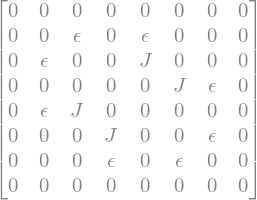

In [57]:
J = sp.Symbol("J", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)
sz = sp.Symbol("sigma_z", real=True, positive=True)

plt.style.use(['science', 'high-vis'])

N = 3 # number of sites
manifold = [3,5,6] # the rows/columns of the generic jump operators which correspond to our desired manifold

# building system hamiltonian
H_flipflop = J*(sigma_plus(0,N)*sigma_minus(1,N)+sigma_plus(1,N)*sigma_minus(0,N))+epsilon*(sigma_plus(0,N)*sigma_minus(2,N)+sigma_plus(2,N)*sigma_minus(0,N))+epsilon*(sigma_plus(1,N)*sigma_minus(2,N)+sigma_plus(2,N)*sigma_minus(1,N))
H_flipflop

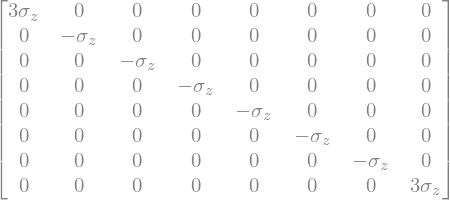

In [52]:
Hz = sz*sigma(sigma_z, 0, N)*sigma(sigma_z, 1, N) + sz*sigma(sigma_z, 0, N)*sigma(sigma_z, 2, N) + sz*sigma(sigma_z, 1, N)*sigma(sigma_z, 2, N)

Hz

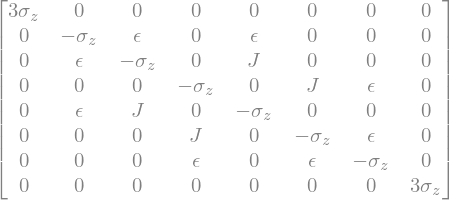

In [53]:
H_full = H_flipflop + Hz

H_full

In [54]:
# buildling matrices
sigma_z_1=np.array(sigma(sigma_z, 0, N)).astype(complex)
sigma_z_2=np.array(sigma(sigma_z, 1, N)).astype(complex)
sigma_z_3=np.array(sigma(sigma_z, 2, N)).astype(complex)

sigma_x_1=np.array(sigma(sigma_x, 0, N)).astype(complex)

# time evolution
def psi(t, H, psi_0):
    return scipy.linalg.expm(-1.0j*np.array(H).astype(complex)*t)@psi_0

# initial condition: $|\psi(t=0)⟩=|1⟩_1 + |0⟩_2 + |0⟩_3$

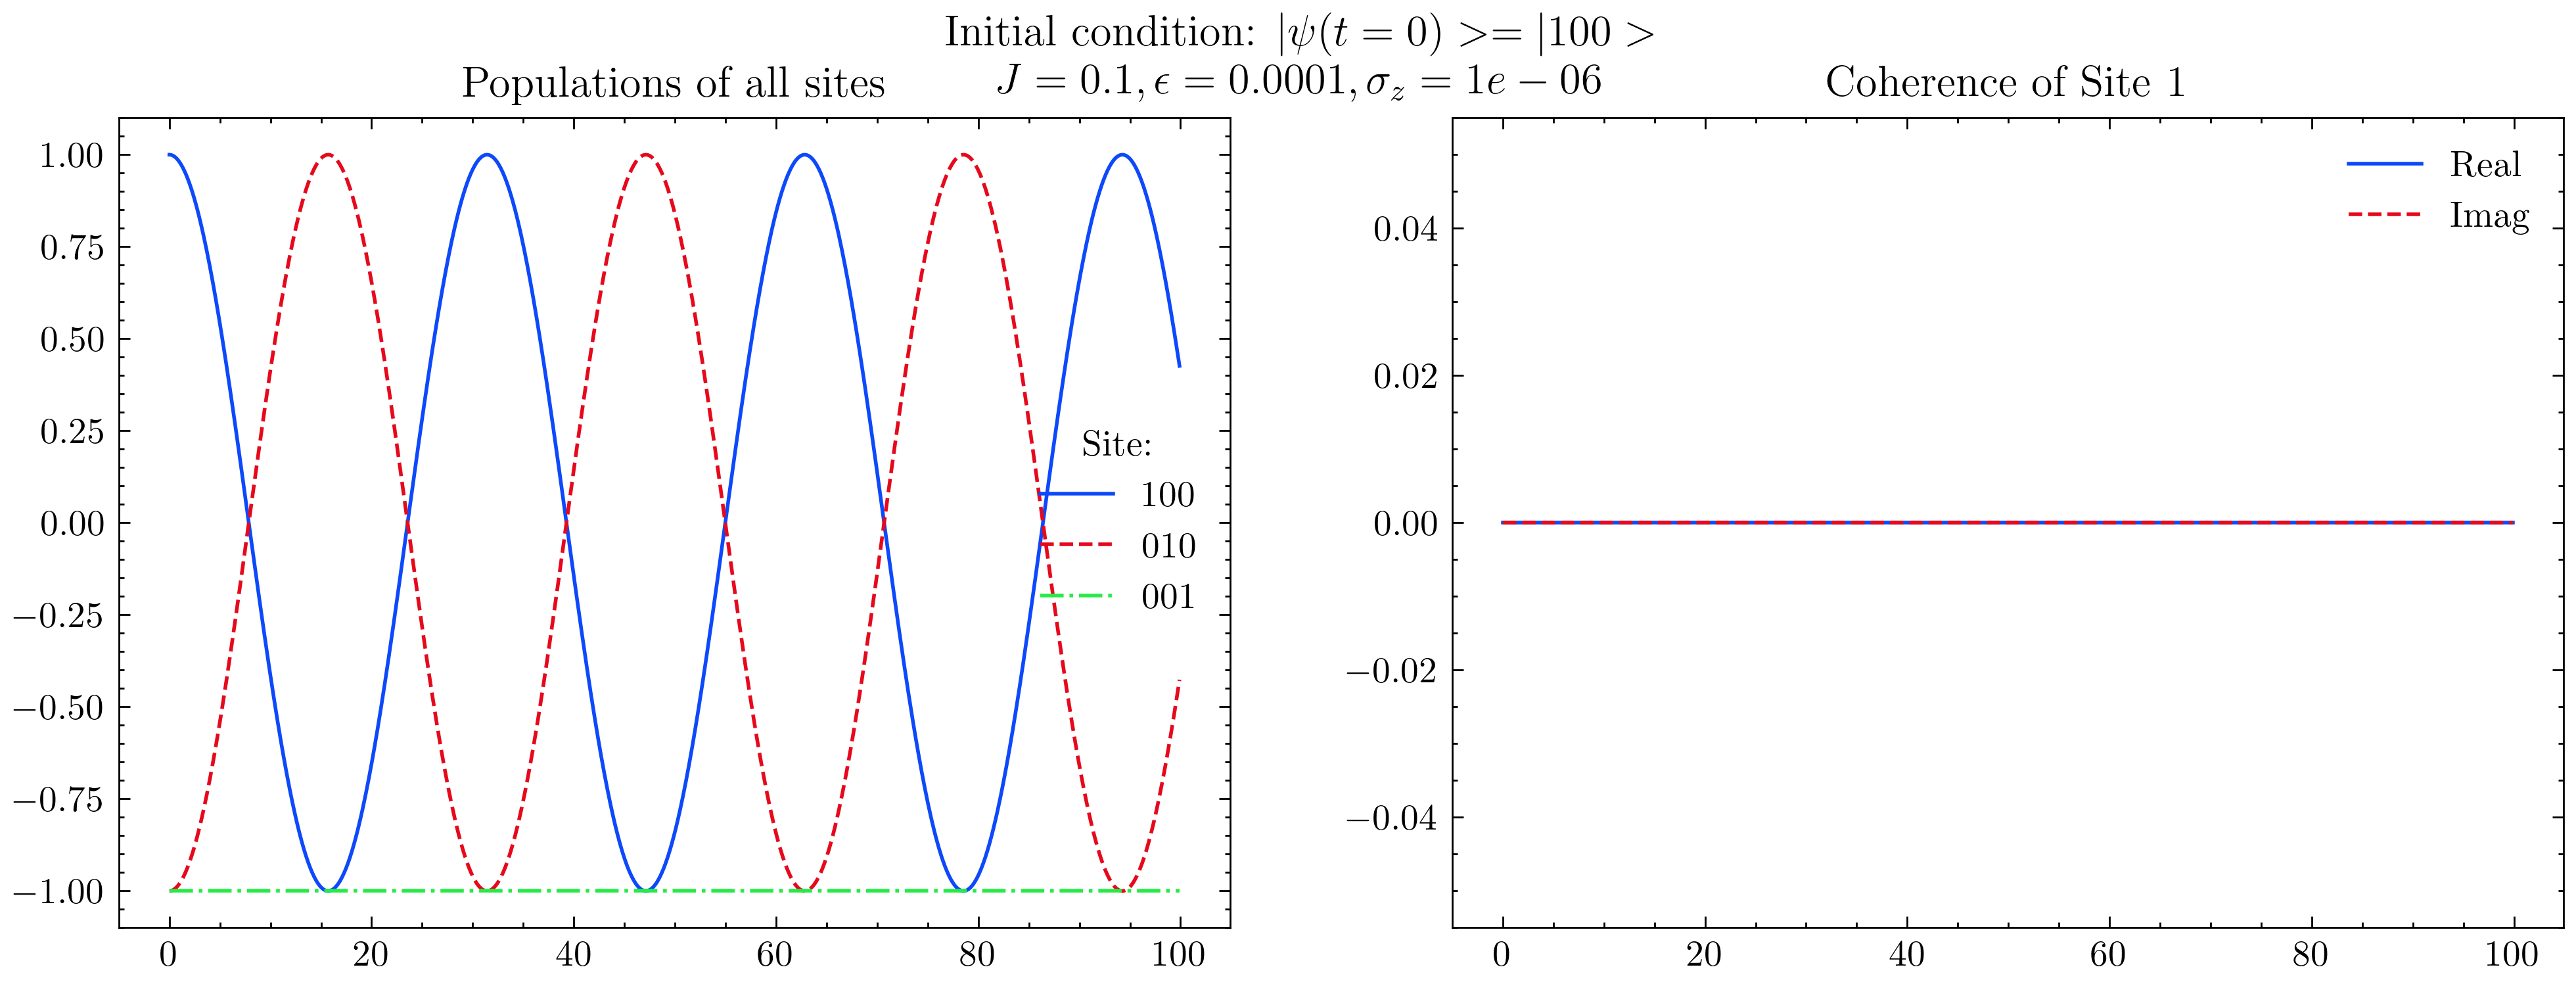

In [68]:
# simulation parameters
time_start = 0
time_stop = 100
time_step = 0.1
times = np.arange(time_start, time_stop, time_step)


# constants
J_val = 0.1
epsilon_val = 1e-4
sz_val = 1e-6


# initial conidition
psi_0 = np.array([0,0,0,0,1,0,0,0]).astype(complex)


# subbing values into H
H = H_full.subs({J:J_val, epsilon:epsilon_val, sz:sz_val})

# setting up fig
fig, axs = plt.subplots(1,2, figsize=(12,4))


# computing pops and cohs
pop1 = [-1*psi(time, H, psi_0).conj().transpose()@sigma_z_1@psi(time, H, psi_0) for time in times]
pop2 = [-1*psi(time, H, psi_0).conj().transpose()@sigma_z_2@psi(time, H, psi_0) for time in times]
pop3 = [-1*psi(time, H, psi_0).conj().transpose()@sigma_z_3@psi(time, H, psi_0) for time in times]
coh1 = [psi(time, H, psi_0).conj().transpose()@sigma_x_1@psi(time, H, psi_0) for time in times]


# plotting
axs[0].plot(times, pop1, label="100")
axs[0].plot(times, pop2, label="010")
axs[0].plot(times, pop3, label="001")
axs[0].legend(title="Site:")
axs[0].set_title("Populations of all sites")
axs[1].plot(times, np.real(coh1), label="Real")
axs[1].plot(times, np.imag(coh1), label="Imag")
axs[1].legend()
axs[1].set_title("Coherence of Site 1")

fig.suptitle("Initial condition: " + r"$|\psi(t=0)>=|100>$" + "\n" + fr"$J={J_val}, \epsilon={epsilon_val}, \sigma_z={sz_val}$")

fig.savefig("initially in 1.pdf")


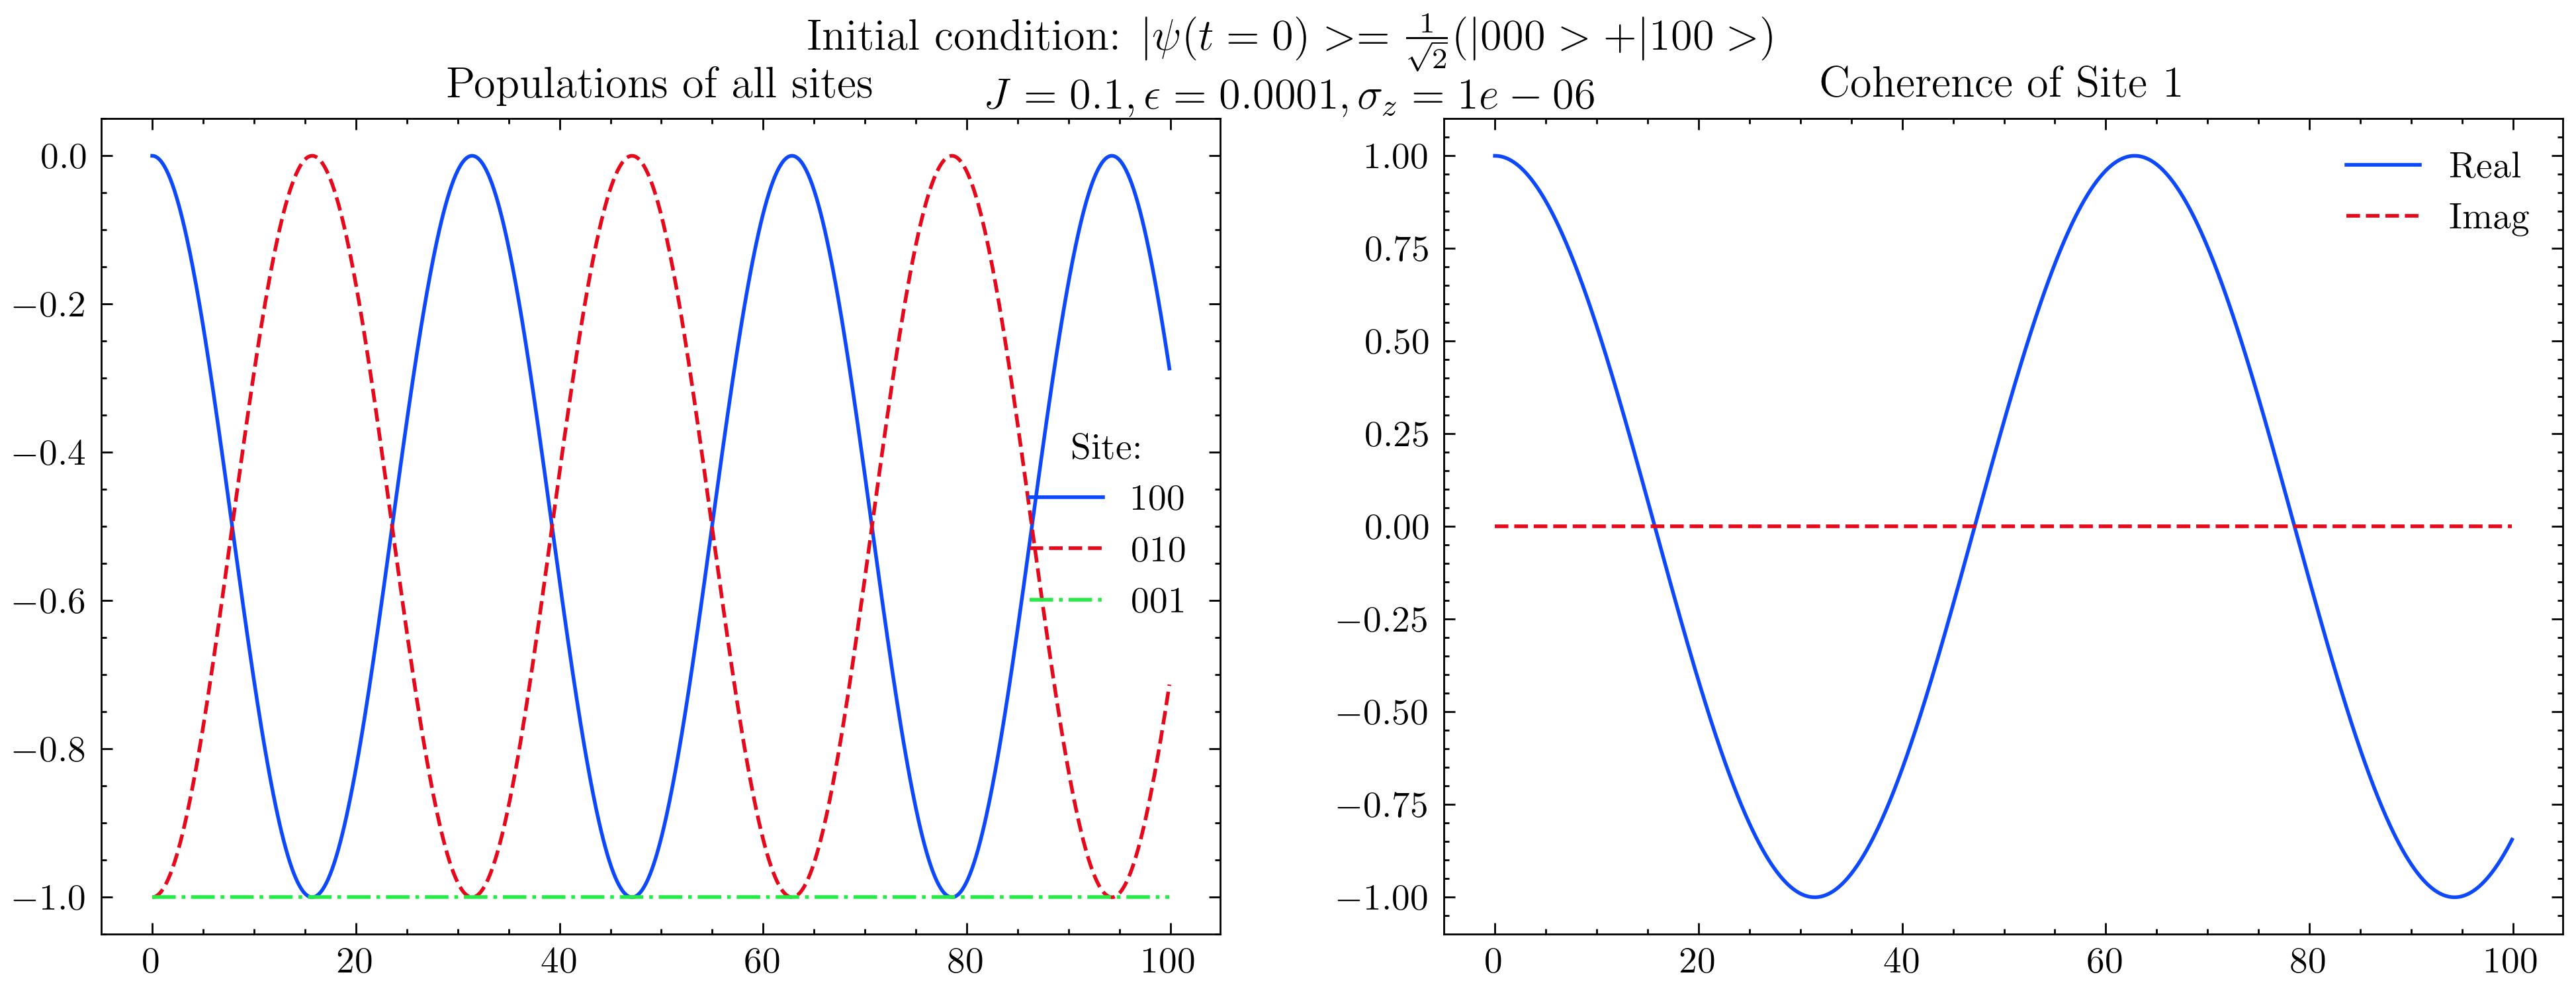

In [93]:
# simulation parameters
time_start = 0
time_stop = 100
time_step = 0.1
times = np.arange(time_start, time_stop, time_step)


# constants
J_val = 0.1
epsilon_val = 1e-4
sz_val = 1e-6


# initial conidition
psi_0 = np.array([1,0,0,0,1,0,0,0])/np.sqrt(2)


# subbing values into H
H = H_full.subs({J:J_val, epsilon:epsilon_val, sz:sz_val})

# setting up fig
fig, axs = plt.subplots(1,2, figsize=(12,4))


# computing pops and cohs
pop1 = [-1*psi(time, H, psi_0).conj().transpose()@sigma_z_1@psi(time, H, psi_0) for time in times]
pop2 = [-1*psi(time, H, psi_0).conj().transpose()@sigma_z_2@psi(time, H, psi_0) for time in times]
pop3 = [-1*psi(time, H, psi_0).conj().transpose()@sigma_z_3@psi(time, H, psi_0) for time in times]
coh1 = [psi(time, H, psi_0).conj().transpose()@sigma_x_1@psi(time, H, psi_0) for time in times]


# plotting
axs[0].plot(times, pop1, label="100")
axs[0].plot(times, pop2, label="010")
axs[0].plot(times, pop3, label="001")
axs[0].legend(title="Site:")
axs[0].set_title("Populations of all sites")
axs[1].plot(times, np.real(coh1), label="Real")
axs[1].plot(times, np.imag(coh1), label="Imag")
axs[1].legend()
#axs[1].ticklabel_format(axis='x', style='sci', scilimits=(0, 0)) 
axs[1].set_title("Coherence of Site 1")

fig.suptitle("Initial condition: " + r"$|\psi(t=0)>=\frac{1}{\sqrt{2}}(|000> +|100>)$" + "\n" + fr"$J={J_val}, \epsilon={epsilon_val}, \sigma_z={sz_val}$")

fig.savefig("initially in superposition.pdf")


# eigenvalue analysis

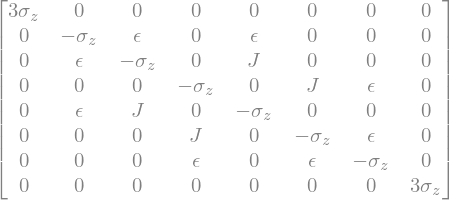

In [85]:
H_full

In [86]:
H, rho = lindbladian(8, H=H_full, dissipative=False)

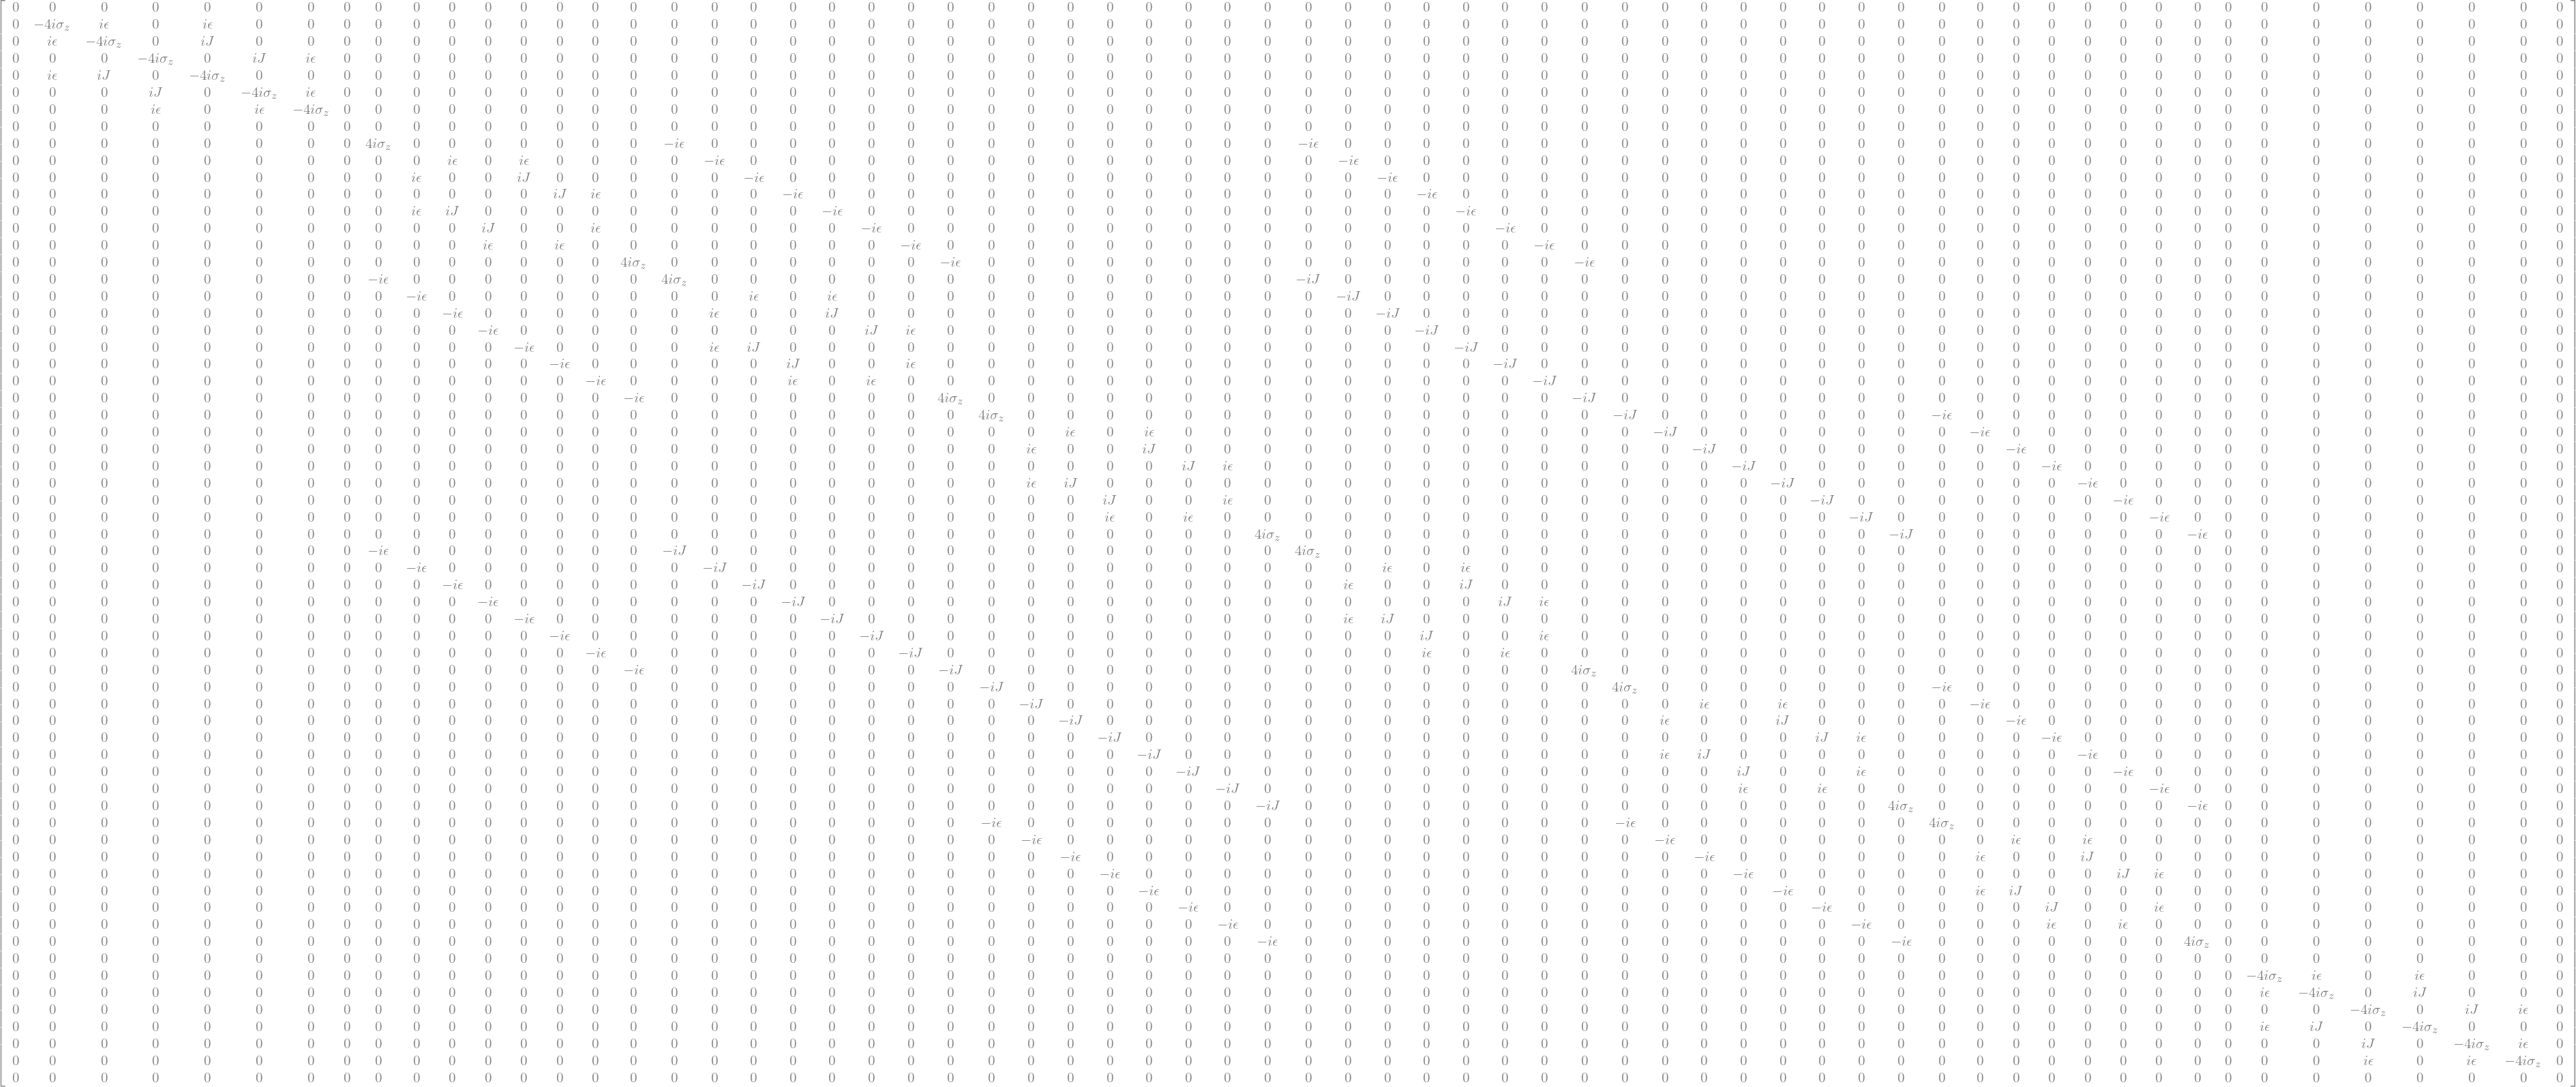

In [87]:
H

In [88]:
evals = []

for val, i in H.eigenvals().items():
    evals.append(val)

In [89]:
for val in evals:
    display(val.subs({J:0.1, epsilon:1e-4, sz:1e-6}))
    print("++++++++++++++++++++++")

++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++++++++


++++++++++++++++


++++++++++++++++


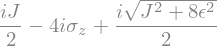

++++++++++++++++


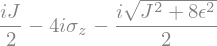

++++++++++++++++


++++++++++++++++


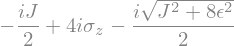

++++++++++++++++


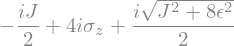

++++++++++++++++


++++++++++++++++


++++++++++++++++


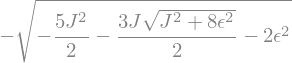

++++++++++++++++


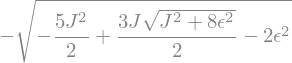

++++++++++++++++


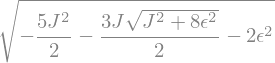

++++++++++++++++


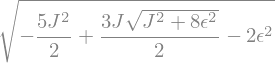

++++++++++++++++


In [90]:
for val in evals:
    display(val)
    print("++++++++++++++++")